# Realized Volatility Bayesian Prediction - clean notebook

This notebook follows the same path as `prep_data.ipynb`, but with the code
cleaned up and the statistical objects named consistently.

The flow is intentionally notebook-like:

1. download prices,
2. prepare realized variance,
3. fit basic HAR,
4. try jump-regime HAR,
5. look at VIX,
6. switch to log-HAR,
7. compare naive benchmarks,
8. fit Bayesian HAR Normal and Student-t,
9. use posterior intervals for warning signals.


## 0. Imports


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import pymc as pm
import arviz as az

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)


g++ not available, if using conda: `conda install gxx`


In [2]:
START = "2010-01-01"
END = "2023-01-01"
TRAIN_FRACTION = 0.80
EPS = 1e-12

# For final results use values like 1000/500/2.
# For quick testing set e.g. DRAWS=100, TUNE=100, CHAINS=1.
DRAWS = 1000
TUNE = 500
CHAINS = 4
TARGET_ACCEPT = 0.90
RANDOM_SEED = 42


## 1. Download market data

This is the same starting point as in `prep_data`: download S&P 500, NASDAQ and
VIX from Yahoo Finance.


In [3]:
try:
    import yfinance.cache as yf_cache
    yf_cache.set_cache_location("data/yfinance_cache")
except Exception:
    pass

tickers = ["^GSPC", "^IXIC", "^VIX"]

data = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
)

data.head()


Price             Close                                 High               \
Ticker            ^GSPC        ^IXIC       ^VIX        ^GSPC        ^IXIC   
Date                                                                        
2010-01-04  1132.989990  2308.419922  20.040001  1133.869995  2311.149902   
2010-01-05  1136.520020  2308.709961  19.350000  1136.630005  2313.729980   
2010-01-06  1137.140015  2301.090088  19.160000  1139.189941  2314.070068   
2010-01-07  1141.689941  2300.050049  19.059999  1142.459961  2301.300049   
2010-01-08  1144.979980  2317.169922  18.129999  1145.390015  2317.600098   

Price                          Low                                 Open  \
Ticker           ^VIX        ^GSPC        ^IXIC       ^VIX        ^GSPC   
Date                                                                      
2010-01-04  21.680000  1116.560059  2294.409912  20.030001  1116.560059   
2010-01-05  20.129999  1129.660034  2295.620117  19.340000  1132.660034   
2010-01-06  19.680000  1133.949951  2295.679932  18.770000  1135.709961   
2010-01-07  19.709999  1131.319946  2285.219971  18.700001  1136.270020   
2010-01-08  19.270000  1136.219971  2290.610107  18.110001  1140.520020   

Price                                   Volume                   
Ticker            ^IXIC       ^VIX       ^GSPC       ^IXIC ^VIX  
Date                                                             
2010-01-04  2294.409912  21.680000  3991400000  1931380000    0  
2010-01-05  2307.270020  20.049999  2491020000  2367860000    0  
2010-01-06  2307.709961  19.590000  4972660000  2253340000    0  
2010-01-07  2298.090088  19.680000  5270680000  2270050000    0  
2010-01-08  2292.239990  19.270000  4389590000  2145390000    0

In [4]:
close = data["Close"]
close.head()


Ticker,^GSPC,^IXIC,^VIX
Date,,,
2010-01-04,1132.989990,2308.419922,20.040001
2010-01-05,1136.520020,2308.709961,19.350000
2010-01-06,1137.140015,2301.090088,19.160000
2010-01-07,1141.689941,2300.050049,19.059999
2010-01-08,1144.979980,2317.169922,18.129999


In [5]:
close = close.rename(columns={
    "^GSPC": "SP500",
    "^IXIC": "NASDAQ",
    "^VIX": "VIX",
})

close.head()


Ticker,SP500,NASDAQ,VIX
Date,,,
2010-01-04,1132.989990,2308.419922,20.040001
2010-01-05,1136.520020,2308.709961,19.350000
2010-01-06,1137.140015,2301.090088,19.160000
2010-01-07,1141.689941,2300.050049,19.059999
2010-01-08,1144.979980,2317.169922,18.129999


In [6]:
close.columns


Index(['SP500', 'NASDAQ', 'VIX'], dtype='str', name='Ticker')

## 2. First pass: HAR model on S&P 500 realized variance

We start exactly like in `prep_data`: take S&P 500, compute daily log returns,
realized variance, lagged HAR features and 5-day forward realized variance.


In [7]:
df = close["SP500"]
df = df.to_frame()
df.columns


Index(['SP500'], dtype='str')

In [8]:
df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df[["SP500", "Ret_1d", "RV_1d", "RV_lag_1", "RV_mean_5", "RV_mean_22"]].head(25)


,SP500,Ret_1d,RV_1d,RV_lag_1,RV_mean_5,RV_mean_22
Date,,,,,,
2010-01-04,1132.989990,NaN,NaN,NaN,NaN,NaN
2010-01-05,1136.520020,0.003111,9.677276e-06,NaN,NaN,NaN
2010-01-06,1137.140015,0.000545,2.974305e-07,9.677276e-06,NaN,NaN
2010-01-07,1141.689941,0.003993,1.594579e-05,2.974305e-07,NaN,NaN
2010-01-08,1144.979980,0.002878,8.280484e-06,1.594579e-05,NaN,NaN
2010-01-11,1146.979980,0.001745,3.045833e-06,8.280484e-06,NaN,NaN
2010-01-12,1136.219971,-0.009425,8.883904e-05,3.045833e-06,0.000007,NaN
2010-01-13,1145.680054,0.008291,6.874825e-05,8.883904e-05,0.000023,NaN
2010-01-14,1148.459961,0.002423,5.873286e-06,6.874825e-05,0.000037,NaN


In [9]:
df["RV_forward_5"] = (
    df["RV_1d"].shift(-1)
    + df["RV_1d"].shift(-2)
    + df["RV_1d"].shift(-3)
    + df["RV_1d"].shift(-4)
    + df["RV_1d"].shift(-5)
) / 5

df[["RV_1d", "RV_forward_5"]].tail(10)


,RV_1d,RV_forward_5
Date,,
2022-12-16,0.000125,0.000109
2022-12-19,0.000082,0.000096
2022-12-20,0.000001,0.000125
2022-12-21,0.000218,0.000142
2022-12-22,0.000212,0.000101
2022-12-23,0.000034,NaN
2022-12-27,0.000016,NaN
2022-12-28,0.000146,NaN
2022-12-29,0.000300,NaN


In [10]:
features = ["RV_lag_1", "RV_mean_5", "RV_mean_22"]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]

split_idx = int(len(model_df) * TRAIN_FRACTION)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))


MSE: 2.3968912911748964e-08
RMSE: 0.00015481896819107458
R2: -0.026149367765600617


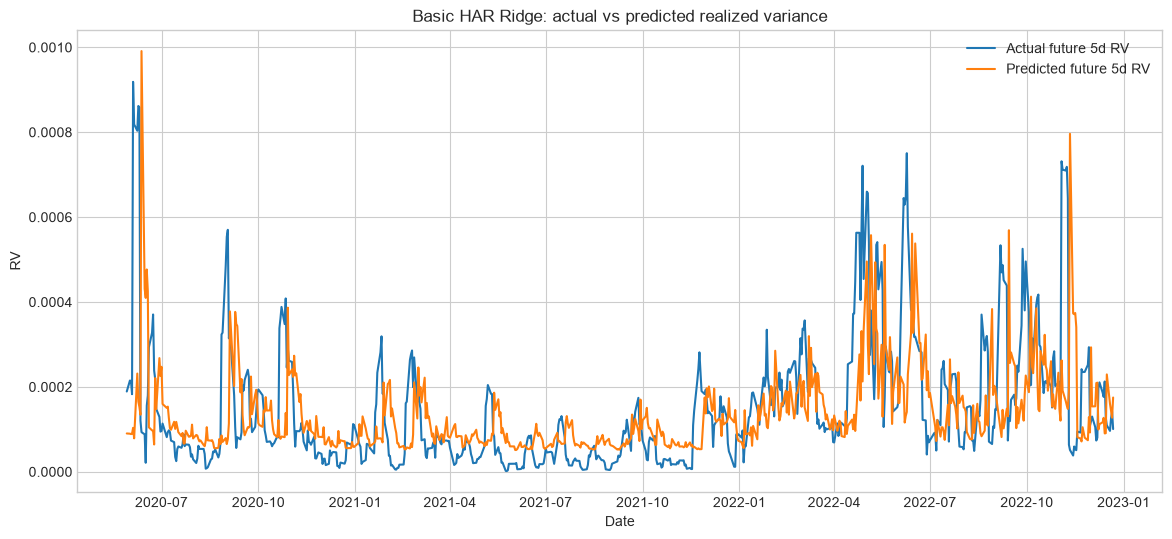

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Actual future 5d RV")
plt.plot(y_test.index, y_test_pred, label="Predicted future 5d RV")
plt.title("Basic HAR Ridge: actual vs predicted realized variance")
plt.xlabel("Date")
plt.ylabel("RV")
plt.legend()
plt.show()


## 3. Jump-regime idea

In the basic HAR plot, the forecast is smooth and tends to lag volatility spikes.
So we add a simple jump/regime signal:

$$JS_t = \frac{RV^{-5}_t}{RV^{-22}_t}.$$

If the recent weekly volatility is more than twice the monthly volatility, we
mark a jump regime:

$$JR_t = 1(JS_t > 2).$$

Then we interact this regime with the HAR variables.


In [12]:
df = close["SP500"].to_frame()

df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df["vol_jump_signal"] = df["RV_mean_5"] / (df["RV_mean_22"] + EPS)
df["jump_regime"] = (df["vol_jump_signal"] > 2).astype(int)

df["RV_lag_1_jump"] = df["RV_lag_1"] * df["jump_regime"]
df["RV_mean_5_jump"] = df["RV_mean_5"] * df["jump_regime"]
df["RV_mean_22_jump"] = df["RV_mean_22"] * df["jump_regime"]

df["RV_forward_5"] = sum(
    df["RV_1d"].shift(-i) for i in range(1, 6)
) / 5

df[["RV_mean_5", "RV_mean_22", "vol_jump_signal", "jump_regime"]].dropna().head()


,RV_mean_5,RV_mean_22,vol_jump_signal,jump_regime
Date,,,,
2010-02-05,0.000299,0.000143,2.086573,1
2010-02-08,0.000281,0.000143,1.962916,0
2010-02-09,0.000257,0.000147,1.749618,0
2010-02-10,0.000257,0.000154,1.673279,0
2010-02-11,0.000252,0.000154,1.642177,0


In [13]:
features = [
    "RV_lag_1",
    "RV_mean_5",
    "RV_mean_22",
    "vol_jump_signal",
    "jump_regime",
    "RV_lag_1_jump",
    "RV_mean_5_jump",
    "RV_mean_22_jump",
]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]

split_idx = int(len(model_df) * TRAIN_FRACTION)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

jump_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

jump_model.fit(X_train, y_train)
y_test_pred = jump_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))


RMSE: 0.00018986110522399116
R2: -0.5432427799230541


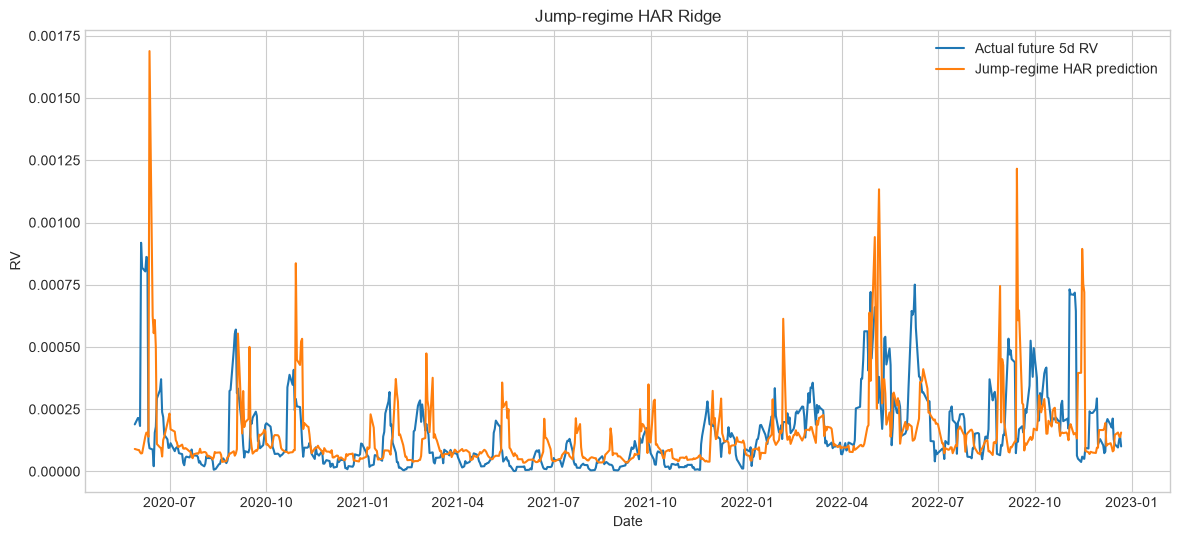

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Actual future 5d RV")
plt.plot(y_test.index, y_test_pred, label="Jump-regime HAR prediction")
plt.title("Jump-regime HAR Ridge")
plt.xlabel("Date")
plt.ylabel("RV")
plt.legend()
plt.show()


## 4. Quick VIX check

Like in `prep_data`, we briefly repeat the realized-variance construction for
VIX. This is mainly exploratory: VIX can later be used as an exogenous predictor
for S&P 500 volatility.


In [15]:
df_vix = close["VIX"].to_frame()
df_vix.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 3272 entries, 2010-01-04 to 2022-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VIX     3272 non-null   float64
dtypes: float64(1)
memory usage: 51.1 KB


In [16]:
df_vix["Ret_1d"] = np.log(df_vix["VIX"] / df_vix["VIX"].shift(1))
df_vix["RV_1d"] = df_vix["Ret_1d"] ** 2

df_vix["RV_lag_1"] = df_vix["RV_1d"].shift(1)
df_vix["RV_mean_5"] = df_vix["RV_1d"].shift(1).rolling(5).mean()
df_vix["RV_mean_22"] = df_vix["RV_1d"].shift(1).rolling(22).mean()

df_vix["RV_forward_5"] = (
    df_vix["RV_1d"].shift(-1)
    + df_vix["RV_1d"].shift(-2)
    + df_vix["RV_1d"].shift(-3)
    + df_vix["RV_1d"].shift(-4)
    + df_vix["RV_1d"].shift(-5)
) / 5

features = ["RV_lag_1", "RV_mean_5", "RV_mean_22"]
target = "RV_forward_5"

vix_model_df = df_vix[[target] + features].dropna()
X = vix_model_df[features]
y = vix_model_df[target]

split_idx = int(len(vix_model_df) * TRAIN_FRACTION)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

vix_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])
vix_model.fit(X_train, y_train)
y_test_pred = vix_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))


MSE: 6.828780723462725e-05
RMSE: 0.008263643702061898
R2: -0.007561487192624394


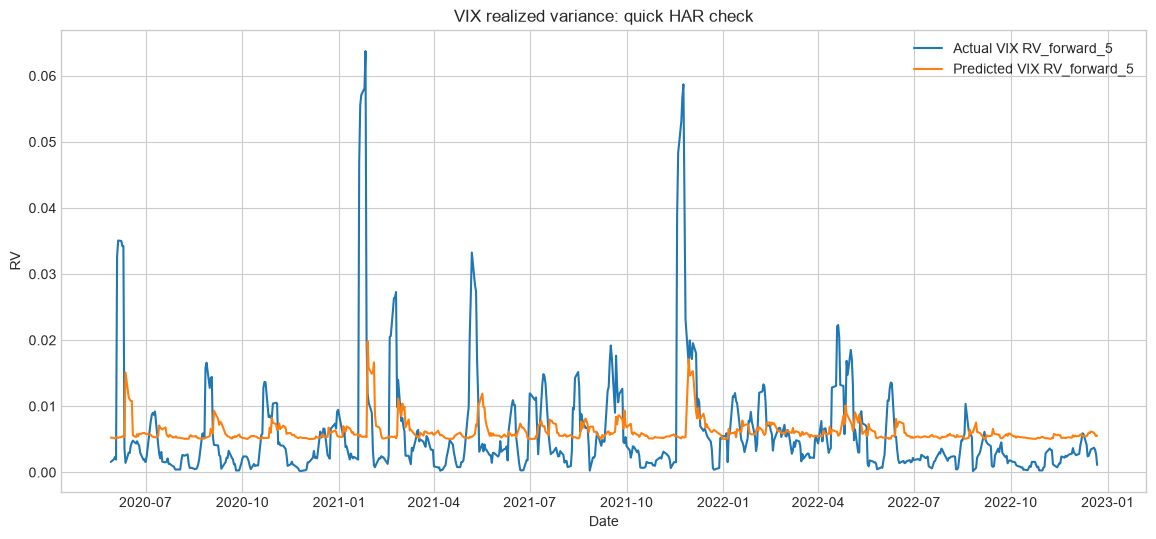

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Actual VIX RV_forward_5")
plt.plot(y_test.index, y_test_pred, label="Predicted VIX RV_forward_5")
plt.title("VIX realized variance: quick HAR check")
plt.xlabel("Date")
plt.ylabel("RV")
plt.legend()
plt.show()


## 5. Log-HAR model for S&P 500

The raw RV scale is very spiky and strictly positive. Now we move to the more
stable model used later in the presentation:

$$\log(RV^{mean}_t) = \beta_0 + \beta_1\log(RV^{-1}_t) + \beta_2\log(RV^{-5}_t) + \beta_3\log(RV^{-22}_t) + \epsilon_t.$$

Predictions are converted back to RV by exponentiating.


In [18]:
df = close["SP500"].to_frame()

df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df["RV_forward_5"] = sum(
    df["RV_1d"].shift(-i) for i in range(1, 6)
) / 5

df["log_RV_lag_1"] = np.log(df["RV_lag_1"] + EPS)
df["log_RV_mean_5"] = np.log(df["RV_mean_5"] + EPS)
df["log_RV_mean_22"] = np.log(df["RV_mean_22"] + EPS)
df["log_RV_forward_5"] = np.log(df["RV_forward_5"] + EPS)

features = ["log_RV_lag_1", "log_RV_mean_5", "log_RV_mean_22"]
target = "log_RV_forward_5"

model_df = df[features + [target, "RV_forward_5"]].dropna()

X = model_df[features]
y = model_df[target]

split_idx = int(len(model_df) * TRAIN_FRACTION)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
model_df_test = model_df.iloc[split_idx:]
rv_true = model_df_test["RV_forward_5"].values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
model_df.head()


Train shape: (2595, 3)
Test shape: (649, 3)


,log_RV_lag_1,log_RV_mean_5,log_RV_mean_22,log_RV_forward_5,RV_forward_5
Date,,,,,
2010-02-05,-6.906928,-8.114848,-8.850371,-9.559970,0.000070
2010-02-08,-11.690971,-8.176355,-8.850786,-9.042281,0.000118
2010-02-09,-9.442778,-8.266645,-8.826043,-9.334693,0.000088
2010-02-10,-8.692417,-8.265312,-8.780097,-9.251968,0.000096
2010-02-11,-12.206966,-8.285046,-8.781069,-9.454777,0.000078


In [19]:
def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.maximum(np.asarray(y_true), eps)
    y_pred = np.maximum(np.asarray(y_pred), eps)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)


def evaluate_point_model(name, y_true_log, y_pred_log, rv_true):
    rv_pred = np.exp(y_pred_log)
    return {
        "model": name,
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_RV": np.sqrt(mean_squared_error(rv_true, rv_pred)),
        "MAE_RV": mean_absolute_error(rv_true, rv_pred),
        "R2_RV": r2_score(rv_true, rv_pred),
        "QLIKE": qlike(rv_true, rv_pred),
    }


In [20]:
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_log_ols = ols.predict(X_test)
rv_pred_ols = np.exp(y_pred_log_ols)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])
ridge_model.fit(X_train, y_train)
y_pred_log_ridge = ridge_model.predict(X_test)
rv_pred_ridge = np.exp(y_pred_log_ridge)

results = pd.DataFrame([
    evaluate_point_model("OLS HAR log(RV)", y_test.values, y_pred_log_ols, rv_true),
    evaluate_point_model("Ridge HAR log(RV)", y_test.values, y_pred_log_ridge, rv_true),
])

results


,model,RMSE_log,MAE_log,R2_log,RMSE_RV,MAE_RV,R2_RV,QLIKE
0,OLS HAR log(RV),0.973811,0.765658,0.239203,0.000153,0.00009,-0.002227,0.682492
1,Ridge HAR log(RV),0.973820,0.765673,0.239190,0.000153,0.00009,-0.002313,0.682515


In [21]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": ols.coef_,
})

print("OLS intercept:", ols.intercept_)
coef_df


OLS intercept: -2.938471479635189


,feature,coefficient
0,log_RV_lag_1,0.022832
1,log_RV_mean_5,0.320375
2,log_RV_mean_22,0.370478


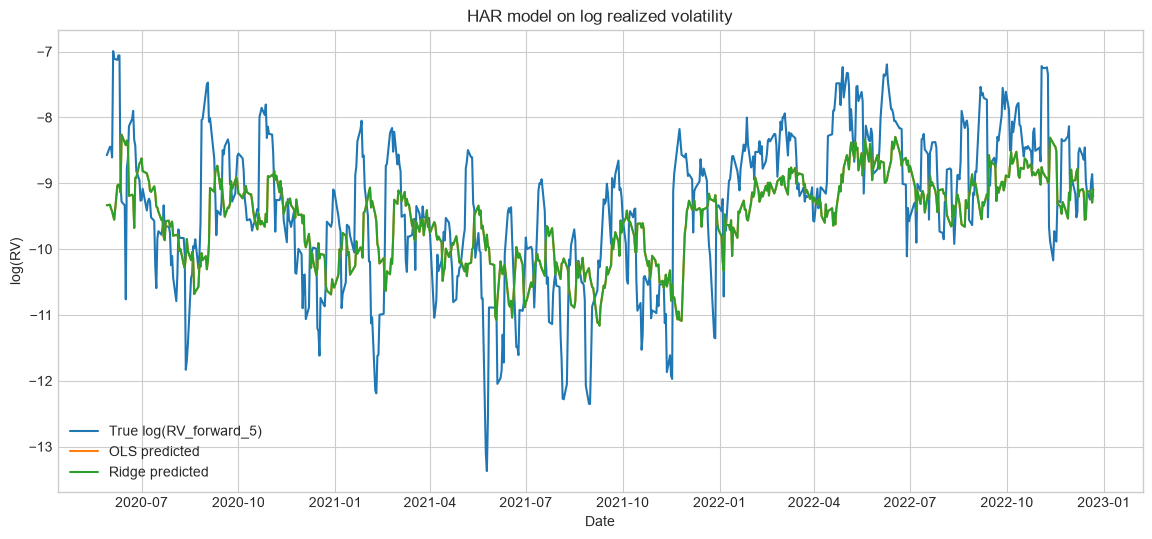

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="True log(RV_forward_5)")
plt.plot(y_test.index, y_pred_log_ols, label="OLS predicted")
plt.plot(y_test.index, y_pred_log_ridge, label="Ridge predicted")
plt.title("HAR model on log realized volatility")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


## 6. Correlations and naive predictions

Before Bayesian modeling, compare the log-HAR model with naive predictors. This
checks whether the regression adds anything beyond simply using yesterday, last
week, or last month volatility.


In [23]:
model_df[[target] + features].corr()


,log_RV_forward_5,log_RV_lag_1,log_RV_mean_5,log_RV_mean_22
log_RV_forward_5,1.000000,0.321109,0.565861,0.565439
log_RV_lag_1,0.321109,1.000000,0.506812,0.370775
log_RV_mean_5,0.565861,0.506812,1.000000,0.764973
log_RV_mean_22,0.565439,0.370775,0.764973,1.000000


In [24]:
naive_preds = {
    "Naive log_RV_lag_1": X_test["log_RV_lag_1"].values,
    "Naive log_RV_mean_5": X_test["log_RV_mean_5"].values,
    "Naive log_RV_mean_22": X_test["log_RV_mean_22"].values,
}

naive_results = pd.DataFrame([
    evaluate_point_model(name, y_test.values, pred, rv_true)
    for name, pred in naive_preds.items()
])

naive_results


,model,RMSE_log,MAE_log,R2_log,RMSE_RV,MAE_RV,R2_RV,QLIKE
0,Naive log_RV_lag_1,2.440218,1.809961,-3.777233,0.000306,0.000161,-2.997156,163.238836
1,Naive log_RV_mean_5,1.156885,0.896098,-0.073741,0.000179,0.000112,-0.373977,1.073382
2,Naive log_RV_mean_22,1.012869,0.793713,0.176951,0.000146,0.000098,0.085497,0.530880


## 7. Bayesian HAR models

Now we use the same log-HAR design matrix, but estimate it Bayesianly.

Normal model:

$$y_t \sim N(\mu_t, \sigma).$$

Student-t model:

$$y_t \sim t_\nu(\mu_t, \sigma), \quad \nu = 2 + \operatorname{Exp}(1/10).$$

The Student-t likelihood is important because volatility residuals are usually
heavy-tailed.


In [25]:
def evaluate_bayesian_predictions(name, y_true_log, pred_samples_log, rv_true):
    pred_mean_log = pred_samples_log.mean(axis=0)

    lower_80_log = np.quantile(pred_samples_log, 0.10, axis=0)
    upper_80_log = np.quantile(pred_samples_log, 0.90, axis=0)
    lower_95_log = np.quantile(pred_samples_log, 0.025, axis=0)
    upper_95_log = np.quantile(pred_samples_log, 0.975, axis=0)

    rv_pred_mean = np.exp(pred_mean_log)
    lower_80_rv = np.exp(lower_80_log)
    upper_80_rv = np.exp(upper_80_log)
    lower_95_rv = np.exp(lower_95_log)
    upper_95_rv = np.exp(upper_95_log)

    result = evaluate_point_model(name, y_true_log, pred_mean_log, rv_true)
    result.update({
        "coverage_80_log": np.mean((y_true_log >= lower_80_log) & (y_true_log <= upper_80_log)),
        "coverage_95_log": np.mean((y_true_log >= lower_95_log) & (y_true_log <= upper_95_log)),
        "avg_width_80_log": np.mean(upper_80_log - lower_80_log),
        "avg_width_95_log": np.mean(upper_95_log - lower_95_log),
        "coverage_80_RV": np.mean((rv_true >= lower_80_rv) & (rv_true <= upper_80_rv)),
        "coverage_95_RV": np.mean((rv_true >= lower_95_rv) & (rv_true <= upper_95_rv)),
        "avg_width_80_RV": np.mean(upper_80_rv - lower_80_rv),
        "avg_width_95_RV": np.mean(upper_95_rv - lower_95_rv),
    })

    intervals = {
        "pred_mean_log": pred_mean_log,
        "lower_80_log": lower_80_log,
        "upper_80_log": upper_80_log,
        "lower_95_log": lower_95_log,
        "upper_95_log": upper_95_log,
        "rv_pred_mean": rv_pred_mean,
        "lower_80_rv": lower_80_rv,
        "upper_80_rv": upper_80_rv,
        "lower_95_rv": lower_95_rv,
        "upper_95_rv": upper_95_rv,
    }

    return result, intervals


In [26]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

coords_train = {
    "obs_id": np.arange(X_train_scaled.shape[0]),
    "feature": features,
}

with pm.Model(coords=coords_train) as normal_model:
    X_data = pm.Data("X_data", X_train_scaled, dims=("obs_id", "feature"))
    y_data = pm.Data("y_data", y_train_scaled, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0.0, sigma=1.0)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="feature")
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta), dims="obs_id")

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims="obs_id",
    )

    normal_idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [31]:
normal_posterior = normal_idata.posterior.stack(sample=("chain", "draw"))

alpha_samples = normal_posterior["alpha"].values
beta_samples = normal_posterior["beta"].transpose("sample", "feature").values
sigma_samples = normal_posterior["sigma"].values

mu_test_scaled = alpha_samples[:, None] + beta_samples @ X_test_scaled.T
rng = np.random.default_rng(RANDOM_SEED)
normal_pred_scaled = rng.normal(mu_test_scaled, sigma_samples[:, None])

normal_pred_log = y_scaler.inverse_transform(
    normal_pred_scaled.reshape(-1, 1)
).reshape(normal_pred_scaled.shape)

normal_results, normal_intervals = evaluate_bayesian_predictions(
    "Bayesian HAR Normal",
    y_test.values,
    normal_pred_log,
    rv_true,
)


AttributeError: 'DataTree' object has no attribute 'stack'

In [32]:
with pm.Model(coords=coords_train) as student_model:
    X_data = pm.Data("X_data", X_train_scaled, dims=("obs_id", "feature"))
    y_data = pm.Data("y_data", y_train_scaled, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0.0, sigma=1.0)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="feature")
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    nu_minus_two = pm.Exponential("nu_minus_two", lam=1 / 10)
    nu = pm.Deterministic("nu", nu_minus_two + 2)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta), dims="obs_id")

    y_obs = pm.StudentT(
        "y_obs",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims="obs_id",
    )

    student_idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma, nu_minus_two]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [33]:
student_posterior = student_idata.posterior.stack(sample=("chain", "draw"))

alpha_samples = student_posterior["alpha"].values
beta_samples = student_posterior["beta"].transpose("sample", "feature").values
sigma_samples = student_posterior["sigma"].values
nu_samples = student_posterior["nu"].values

mu_test_scaled = alpha_samples[:, None] + beta_samples @ X_test_scaled.T
student_pred_scaled = mu_test_scaled + sigma_samples[:, None] * rng.standard_t(
    df=nu_samples[:, None],
    size=mu_test_scaled.shape,
)

student_pred_log = y_scaler.inverse_transform(
    student_pred_scaled.reshape(-1, 1)
).reshape(student_pred_scaled.shape)

student_results, student_intervals = evaluate_bayesian_predictions(
    "Bayesian HAR Student-t",
    y_test.values,
    student_pred_log,
    rv_true,
)


AttributeError: 'DataTree' object has no attribute 'stack'

In [34]:
all_results = pd.DataFrame(
    results.to_dict("records")
    + [normal_results, student_results]
)

all_results


NameError: name 'normal_results' is not defined

In [35]:
az.summary(normal_idata, var_names=["alpha", "beta", "sigma"])


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-0.0002,0.0158,-0.026,0.025,2481,1547,1.00,0.00032,0.00023
beta[log_RV_lag_1],0.0471,0.0177,0.018,0.076,2048,1489,1.00,0.00039,0.00028
beta[log_RV_mean_5],0.321,0.0256,0.28,0.36,1349,1319,1.00,0.0007,0.00049
beta[log_RV_mean_22],0.287,0.0235,0.25,0.32,1598,1449,1.00,0.00059,0.00042
sigma,0.8056,0.0111,0.79,0.82,2438,1490,1.00,0.00023,0.00016


In [36]:
az.summary(student_idata, var_names=["alpha", "beta", "sigma", "nu"])


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.0048,0.015,-0.02,0.028,2308,1431,1.00,0.00031,0.00021
beta[log_RV_lag_1],0.046,0.0174,0.019,0.075,2019,1352,1.00,0.00039,0.00028
beta[log_RV_mean_5],0.318,0.026,0.28,0.36,1128,1250,1.00,0.00078,0.00056
beta[log_RV_mean_22],0.296,0.0241,0.26,0.34,1326,1399,1.00,0.00066,0.00047
sigma,0.7223,0.0158,0.7,0.75,1644,1345,1.00,0.00039,0.00028
nu,10.36,1.93,7.8,14,1642,1467,1.00,0.048,0.044


## 8. Bayesian intervals and residuals

The point forecast is only one part of the Bayesian model. The intervals tell us
how uncertain the model is. For volatility warning systems this matters a lot:
sometimes the mean forecast is not above the danger threshold, but the upper
credible/predictive bound is.


NameError: name 'normal_intervals' is not defined

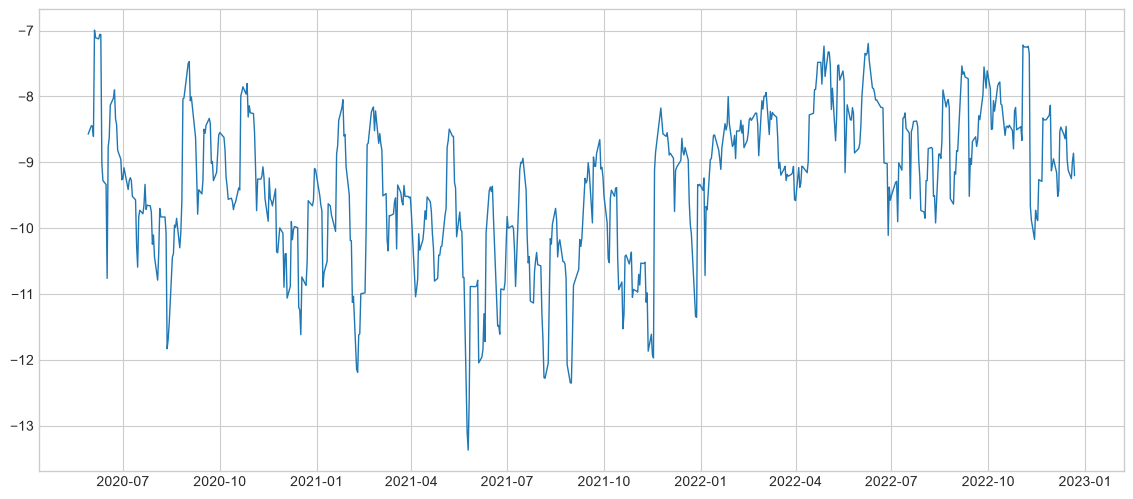

In [37]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="True log(RV_forward_5)", linewidth=1)
plt.plot(y_test.index, normal_intervals["pred_mean_log"], label="Bayesian HAR Normal mean", linewidth=1)
plt.fill_between(
    y_test.index,
    normal_intervals["lower_80_log"],
    normal_intervals["upper_80_log"],
    alpha=0.30,
    label="80% predictive interval",
)
plt.fill_between(
    y_test.index,
    normal_intervals["lower_95_log"],
    normal_intervals["upper_95_log"],
    alpha=0.15,
    label="95% predictive interval",
)
plt.title("Bayesian HAR Normal - posterior predictive intervals")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


NameError: name 'student_intervals' is not defined

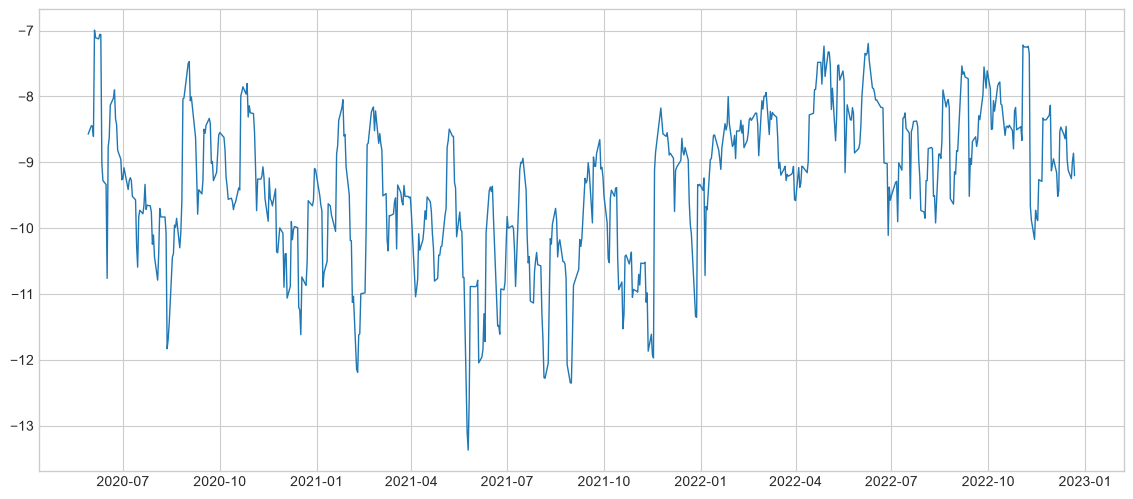

In [38]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="True log(RV_forward_5)", linewidth=1)
plt.plot(y_test.index, student_intervals["pred_mean_log"], label="Bayesian HAR Student-t mean", linewidth=1)
plt.fill_between(
    y_test.index,
    student_intervals["lower_80_log"],
    student_intervals["upper_80_log"],
    alpha=0.30,
    label="80% predictive interval",
)
plt.fill_between(
    y_test.index,
    student_intervals["lower_95_log"],
    student_intervals["upper_95_log"],
    alpha=0.15,
    label="95% predictive interval",
)
plt.title("Bayesian HAR Student-t - posterior predictive intervals")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


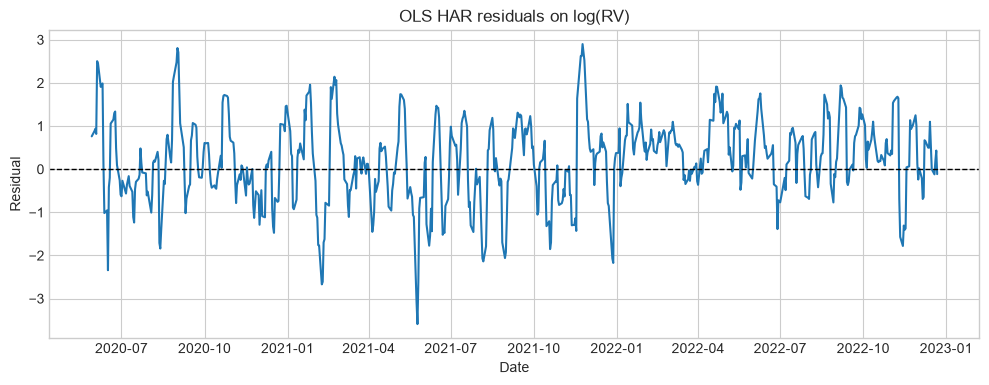

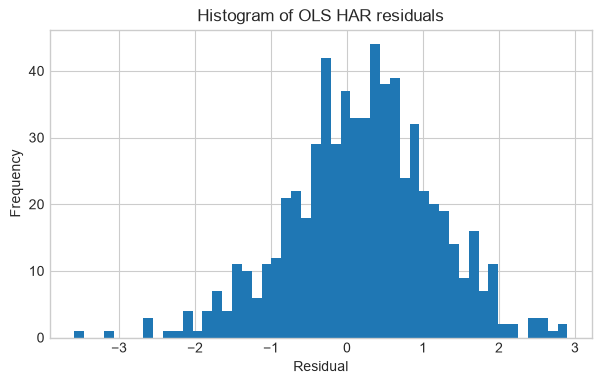

In [39]:
residuals_ols = y_test.values - y_pred_log_ols

plt.figure(figsize=(12, 4))
plt.plot(y_test.index, residuals_ols)
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title("OLS HAR residuals on log(RV)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals_ols, bins=50)
plt.title("Histogram of OLS HAR residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


## 9. Warning signals - more detailed version

The warning problem is not exactly the same as minimizing RMSE.

We define a high-volatility event as:

$$RV^{mean}_t > q_{0.8}(RV^{mean}),$$

so the top 20% of realized future-volatility observations are treated as events.

Then we compare several possible warning rules:

1. **OLS mean forecast**: warning if the classical mean forecast is above the threshold.
2. **Bayesian mean forecast**: warning if the Bayesian posterior predictive mean is above the threshold.
3. **Bayesian upper 80% bound**: warning if the upper 80% predictive bound is above the threshold.
4. **Bayesian upper 95% bound**: warning if the upper 95% predictive bound is above the threshold.

Interpretation:

- high precision means that warnings are usually correct,
- high recall means that most true high-volatility events are caught,
- upper-bound rules usually increase recall but create many more warnings.


In [40]:
signals_df = pd.DataFrame(index=y_test.index)

signals_df["rv_true"] = rv_true
signals_df["ols_pred"] = np.exp(y_pred_log_ols)
signals_df["ridge_pred"] = np.exp(y_pred_log_ridge)
signals_df["bayes_mean"] = student_intervals["rv_pred_mean"]
signals_df["bayes_upper_80"] = student_intervals["upper_80_rv"]
signals_df["bayes_upper_95"] = student_intervals["upper_95_rv"]

threshold = np.quantile(model_df["RV_forward_5"], 0.80)
print("Warning threshold:", threshold)

signals_df["high_vol_realized"] = (signals_df["rv_true"] > threshold).astype(int)
signals_df["warning_ols_mean"] = (signals_df["ols_pred"] > threshold).astype(int)
signals_df["warning_ridge_mean"] = (signals_df["ridge_pred"] > threshold).astype(int)
signals_df["warning_bayes_mean"] = (signals_df["bayes_mean"] > threshold).astype(int)
signals_df["warning_bayes_upper_80"] = (signals_df["bayes_upper_80"] > threshold).astype(int)
signals_df["warning_bayes_upper_95"] = (signals_df["bayes_upper_95"] > threshold).astype(int)

signals_df.head()


NameError: name 'student_intervals' is not defined

In [41]:
def evaluate_warning(name, y_true, y_signal):
    return {
        "signal": name,
        "precision": precision_score(y_true, y_signal, zero_division=0),
        "recall": recall_score(y_true, y_signal, zero_division=0),
        "f1": f1_score(y_true, y_signal, zero_division=0),
        "n_warnings": int(y_signal.sum()),
        "n_high_vol": int(y_true.sum()),
    }

warning_results = pd.DataFrame([
    evaluate_warning(
        "OLS mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_ols_mean"],
    ),
    evaluate_warning(
        "Ridge mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_ridge_mean"],
    ),
    evaluate_warning(
        "Bayesian Student-t mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_mean"],
    ),
    evaluate_warning(
        "Bayesian Student-t upper 80%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_80"],
    ),
    evaluate_warning(
        "Bayesian Student-t upper 95%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_95"],
    ),
])

warning_results


KeyError: 'high_vol_realized'

In [ ]:
for column in [
    "warning_ols_mean",
    "warning_bayes_mean",
    "warning_bayes_upper_80",
    "warning_bayes_upper_95",
]:
    print("\n", column)
    print(confusion_matrix(signals_df["high_vol_realized"], signals_df[column]))


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(signals_df.index, signals_df["rv_true"], label="Realized future 5d RV", linewidth=1)
plt.axhline(threshold, color="black", linestyle="--", label="80% high-vol threshold")
plt.scatter(
    signals_df.index[signals_df["warning_bayes_upper_80"] == 1],
    signals_df.loc[signals_df["warning_bayes_upper_80"] == 1, "rv_true"],
    s=12,
    alpha=0.45,
    label="Bayesian upper 80% warning",
)
plt.title("High-volatility warning signal based on Bayesian upper predictive bound")
plt.xlabel("Date")
plt.ylabel("RV_forward_5")
plt.legend()
plt.show()


## 10. What to write in the conclusions

After running the notebook, focus the interpretation on:

- whether log-HAR improves over raw RV HAR,
- whether the jump-regime variables help or overfit,
- whether Student-t improves QLIKE and interval behavior,
- whether upper-bound warning rules are useful despite lower precision,
- whether VIX should enter the next version as an exogenous predictor for S&P 500 volatility.
